# Phase 2: The "Leave-One-Out" Model Construction
## Agricultural Risk Dashboard

In this notebook we build the mathematical engine that separates commodity-specific (idiosyncratic) risk from general market risk. Starting from the master dataset produced in Phase 1, we construct a dynamic sector index, run rolling multi-factor regressions, extract residuals, and compute rolling Idiosyncratic Volatility for each commodity.

### 2.1 Load Master Dataset

Load the clean master CSV from Phase 1 (`data/processed/master_data.csv`). Verify its shape, date range, and confirm zero missing values. Define the list of agricultural commodities and the list of risk factors (SP500, Crude_Oil, USD_Index) for use throughout the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

# Load master dataset from Phase 1
master = pd.read_csv('data/processed/master_data.csv', parse_dates=['Date'])

# Define asset groups
COMMODITIES = ['Corn', 'Soybean', 'Wheat', 'Cotton', 'Coffee', 'Oats', 'Sugar', 'Soybean_Oil', 'Lumber']
FACTORS = ['SP500', 'Crude_Oil', 'USD_Index']
WINDOW = 126  # rolling window size

# RICI (Rogers International Commodity Index) target weights for the 9 commodities.
# Source: RICI Handbook (January 2026)
# https://www.beelandinterests.com/wp-content/uploads/2024/02/RICI-Handbook_JAN.24.2024.pdf
RICI_WEIGHTS = {
    'Corn':        4.75,
    'Soybean':     3.50,
    'Wheat':       2.75,
    'Cotton':      4.20,
    'Coffee':      2.00,
    'Oats':        0.50,
    'Sugar':       2.00,
    'Soybean_Oil': 2.00,
    'Lumber':      0.90,
}

print(f'Master dataset: {master.shape[0]} rows x {master.shape[1]} columns')
print(f'Date range: {master["Date"].iloc[0].date()} to {master["Date"].iloc[-1].date()}')
print(f'Missing values: {master.isnull().sum().sum()}')
print(f'\nCommodities ({len(COMMODITIES)}): {COMMODITIES}')
print(f'Risk Factors ({len(FACTORS)}): {FACTORS}')
print(f'Rolling window: {WINDOW} days')
print(f'\nRICI target weights (raw %):')
for k, v in RICI_WEIGHTS.items():
    print(f'  {k:<15} {v:>5.2f}%')

Master dataset: 9601 rows x 13 columns
Date range: 1986-01-03 to 2026-03-02
Missing values: 0

Commodities (9): ['Corn', 'Soybean', 'Wheat', 'Cotton', 'Coffee', 'Oats', 'Sugar', 'Soybean_Oil', 'Lumber']
Risk Factors (3): ['SP500', 'Crude_Oil', 'USD_Index']
Rolling window: 126 days

RICI target weights (raw %):
  Corn             4.75%
  Soybean          3.50%
  Wheat            2.75%
  Cotton           4.20%
  Coffee           2.00%
  Oats             0.50%
  Sugar            2.00%
  Soybean_Oil      2.00%
  Lumber           0.90%


### 2.2 Construct the Leave-One-Out Sector Index (RICI-Weighted)

For each target commodity, compute a **"Rest of Sector"** index as a weighted average of the log returns of all *other* agricultural commodities (excluding the target). This avoids circular logic, we cannot explain Corn using an index that already contains Corn.

Instead of equal weighting, we use the published **Rogers International Commodity Index (RICI)** target weights. RICI was chosen over BCOM because RICI includes all 9 commodities in our dataset, whereas BCOM excludes Oats and Lumber. For each target, its weight is removed and the remaining weights are rescaled to sum to 1:

$$R_{sector,t}^{(i)} = \sum_{j \neq i} \tilde{w}_j \cdot r_{j,t}, \quad \text{where} \quad \tilde{w}_j = \frac{w_j^{RICI}}{\sum_{k \neq i} w_k^{RICI}}$$


In [2]:
# Build leave-one-out sector index for each commodity using RICI weights.
# For each target, drop its weight from the other commodities and rescale
# the remaining weights to sum to 1, then take a weighted average.
sector_indices = {}

for target in COMMODITIES:
    others = [c for c in COMMODITIES if c != target]
    weights = np.array([RICI_WEIGHTS[c] for c in others], dtype=float)
    weights = weights / weights.sum()  # rescale so remaining weights sum to 1
    sector_indices[target] = (master[others] * weights).sum(axis=1)

# Show the rescaled weights used for Sector_ex_Corn
corn_others = [c for c in COMMODITIES if c != 'Corn']
corn_weights = np.array([RICI_WEIGHTS[c] for c in corn_others], dtype=float)
corn_weights = corn_weights / corn_weights.sum()

print('Rescaled RICI weights for Sector_ex_Corn:')
for name, w in zip(corn_others, corn_weights):
    print(f'  {name:<15} {w:>7.4f}')
print(f'  {"Sum":<15} {corn_weights.sum():>7.4f}')

# Display sample for Corn
sample = pd.DataFrame({
    'Date': master['Date'],
    'Corn': master['Corn'],
    'Sector_ex_Corn': sector_indices['Corn']
}).head(10)

print('\nLeave-One-Out Sector Index (excluding Corn):')
sample

Rescaled RICI weights for Sector_ex_Corn:
  Soybean          0.1961
  Wheat            0.1541
  Cotton           0.2353
  Coffee           0.1120
  Oats             0.0280
  Sugar            0.1120
  Soybean_Oil      0.1120
  Lumber           0.0504
  Sum              1.0000

Leave-One-Out Sector Index (excluding Corn):


,Date,Corn,Sector_ex_Corn
0,1986-01-03,-0.002112,-0.000849
1,1986-01-06,0.004219,0.004519
2,1986-01-07,0.002103,0.025149
3,1986-01-08,-0.004211,-0.004536
4,1986-01-09,0.000000,-0.000694
5,1986-01-10,0.000000,-0.003026
6,1986-01-13,-0.011671,-0.017298
7,1986-01-14,0.007443,-0.001542
8,1986-01-15,0.010538,0.006586
9,1986-01-16,-0.006309,-0.002623


### 2.3 Rolling Multi-Factor OLS Regression

For each target commodity, run a **126-day rolling window OLS regression** where the target's log return is regressed against four risk factors:

$$r_{i,t} = \alpha + \beta_1 R_{mkt,t} + \beta_2 R_{oil,t} + \beta_3 R_{usd,t} + \beta_4 R_{sector,t} + \epsilon_{i,t}$$

Use `statsmodels` `RollingOLS` for each window, store:
- The **residual** $\epsilon_{i,t}$ of the last observation in the window (the unexplained return).
- The **rolling betas** ($\beta_1$ through $\beta_4$) for later inspection.

The first 125 rows will be NaN (insufficient data for the first window). Run this for all 9 commodities and store results in a structured format.

In [3]:
# Rolling OLS regression for each commodity
residuals = pd.DataFrame({'Date': master['Date']})
rolling_betas = {}

for target in COMMODITIES:
    print(f'Running rolling OLS for {target}...', end=' ')

    y = master[target].values
    X = np.column_stack([
        master['SP500'].values,
        master['Crude_Oil'].values,
        master['USD_Index'].values,
        sector_indices[target].values
    ])
    X = sm.add_constant(X)

    n = len(y)
    res = np.full(n, np.nan)
    betas = np.full((n, 5), np.nan)  # const + 4 factors

    for t in range(WINDOW - 1, n):
        start = t - WINDOW + 1
        y_win = y[start:t + 1]
        X_win = X[start:t + 1]

        model = sm.OLS(y_win, X_win).fit()
        res[t] = model.resid[-1]
        betas[t] = model.params

    residuals[target] = res
    rolling_betas[target] = pd.DataFrame(
        betas,
        columns=['alpha', 'beta_SP500', 'beta_Oil', 'beta_USD', 'beta_Sector']
    )
    rolling_betas[target].insert(0, 'Date', master['Date'])

    print('done')

print(f'\nResiduals shape: {residuals.shape}')
residuals.dropna().head()

Running rolling OLS for Corn... done
Running rolling OLS for Soybean... done
Running rolling OLS for Wheat... done
Running rolling OLS for Cotton... done
Running rolling OLS for Coffee... done
Running rolling OLS for Oats... done
Running rolling OLS for Sugar... done
Running rolling OLS for Soybean_Oil... done
Running rolling OLS for Lumber... done

Residuals shape: (9601, 10)


,Date,Corn,Soybean,Wheat,Cotton,Coffee,Oats,Sugar,Soybean_Oil,Lumber
125,1986-07-09,0.019447,-0.002750,0.011516,-0.000350,-0.002910,-0.008912,-0.009670,-0.005199,0.016161
126,1986-07-10,-0.010710,0.009802,0.020036,-0.000621,0.001129,-0.010777,0.000311,-0.015025,-0.002379
127,1986-07-11,0.010746,0.005607,0.017535,-0.001040,0.001733,0.006037,-0.053153,-0.001900,0.002654
128,1986-07-14,0.005981,0.002728,0.015024,-0.000946,0.001173,0.004108,-0.018171,-0.013771,-0.012364
129,1986-07-15,0.017883,0.006470,-0.014128,-0.000712,0.024367,-0.001575,0.014288,0.003092,-0.010032


### 2.4 Calculate Idiosyncratic Volatility (IVol)

Compute the **rolling standard deviation of the residuals** over the same 126-day window. This is the Idiosyncratic Volatility, the primary signal of commodity-specific risk.

$$IVol_t = \sqrt{\frac{1}{T-1} \sum_{k=0}^{T-1} (\epsilon_{t-k} - \bar{\epsilon})^2}$$

Also compute the **Total Volatility** (rolling std dev of raw log returns) for comparison. Store both IVol and Total Vol for each commodity.

In [4]:
# Calculate rolling Idiosyncratic Volatility and Total Volatility
ivol_df = pd.DataFrame({'Date': master['Date']})
total_vol_df = pd.DataFrame({'Date': master['Date']})

for target in COMMODITIES:
    # IVol: rolling std of residuals
    ivol_df[target] = residuals[target].rolling(window=WINDOW).std()

    # Total Vol: rolling std of raw log returns
    total_vol_df[target] = master[target].rolling(window=WINDOW).std()

print(f'IVol shape: {ivol_df.shape}')
print(f'Total Vol shape: {total_vol_df.shape}')
print(f'Valid rows (after 2x window burn-in): {ivol_df.dropna().shape[0]}')
ivol_df.dropna().head()

IVol shape: (9601, 10)
Total Vol shape: (9601, 10)
Valid rows (after 2x window burn-in): 9351


,Date,Corn,Soybean,Wheat,Cotton,Coffee,Oats,Sugar,Soybean_Oil,Lumber
250,1987-01-15,0.020072,0.009953,0.015174,0.081650,0.012216,0.014863,0.034285,0.015508,0.017211
251,1987-01-16,0.020026,0.009954,0.015159,0.081651,0.012221,0.014862,0.034268,0.015573,0.017171
252,1987-01-19,0.019999,0.009916,0.015077,0.081659,0.012229,0.015049,0.034348,0.015538,0.017187
253,1987-01-20,0.019984,0.009930,0.015014,0.081660,0.012231,0.015092,0.033983,0.015555,0.017277
254,1987-01-21,0.019981,0.009927,0.014976,0.081703,0.012235,0.015135,0.034008,0.015584,0.017414


### 2.5 Visualize: Total Volatility vs. Idiosyncratic Volatility

For each commodity, plot a **dual-line chart** showing Total Volatility and Idiosyncratic Volatility over time. This reveals periods where commodity-specific risk diverges from overall market risk.

Create a grid of subplots (3x3) showing all 9 commodities. Label axes, add a legend, and highlight any visually obvious divergence periods.

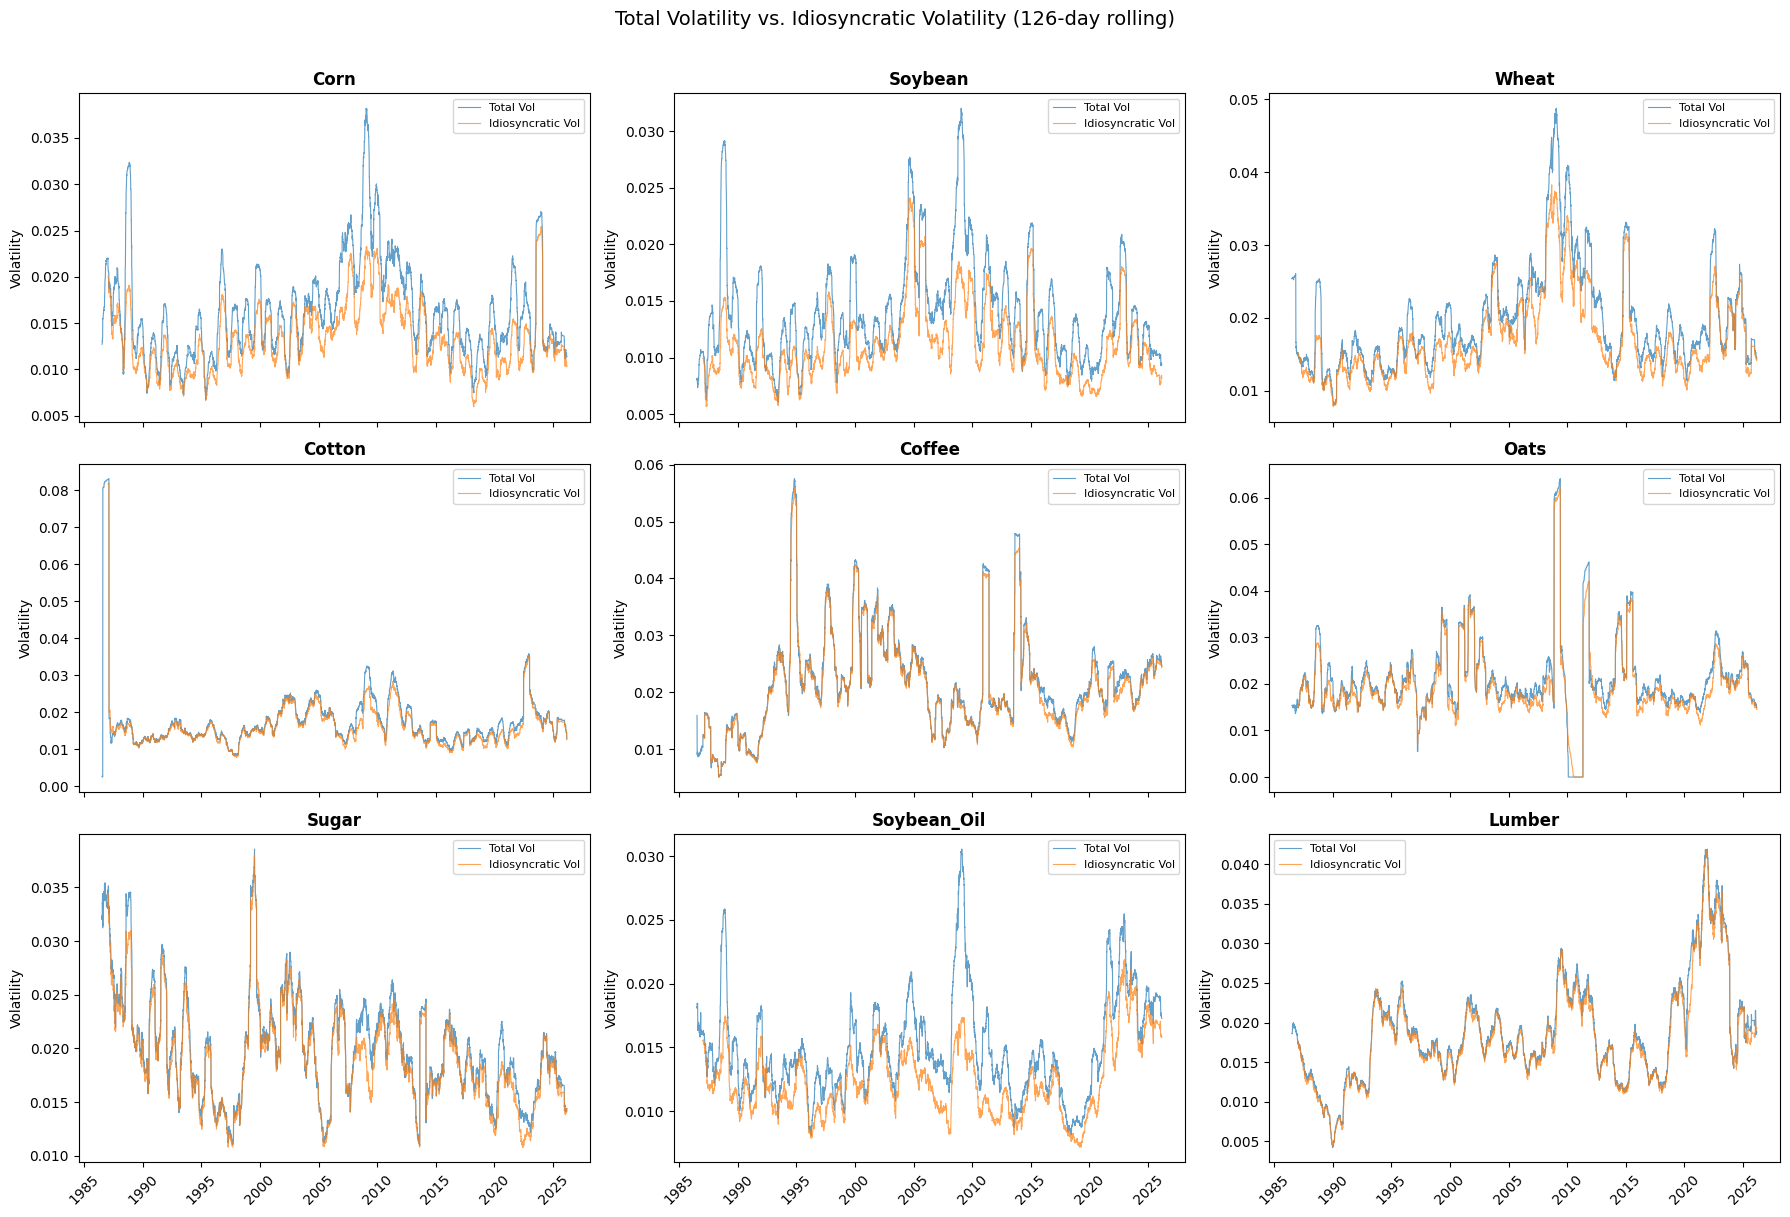

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for idx, target in enumerate(COMMODITIES):
    ax = axes[idx // 3, idx % 3]

    dates = master['Date']
    ax.plot(dates, total_vol_df[target], label='Total Vol', alpha=0.7, linewidth=0.8)
    ax.plot(dates, ivol_df[target], label='Idiosyncratic Vol', alpha=0.7, linewidth=0.8)

    ax.set_title(target, fontsize=12, fontweight='bold')
    ax.set_ylabel('Volatility')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Total Volatility vs. Idiosyncratic Volatility (126-day rolling)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/vol_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Inspect Rolling Betas

Plot the **rolling beta coefficients** ($\beta_1$ through $\beta_4$) over time for a selected commodity (e.g., Corn). This shows how the commodity's sensitivity to Market, Oil, USD, and the Sector evolves. This helps confirming that the model captures time-varying factor exposures rather than assuming static relationships.

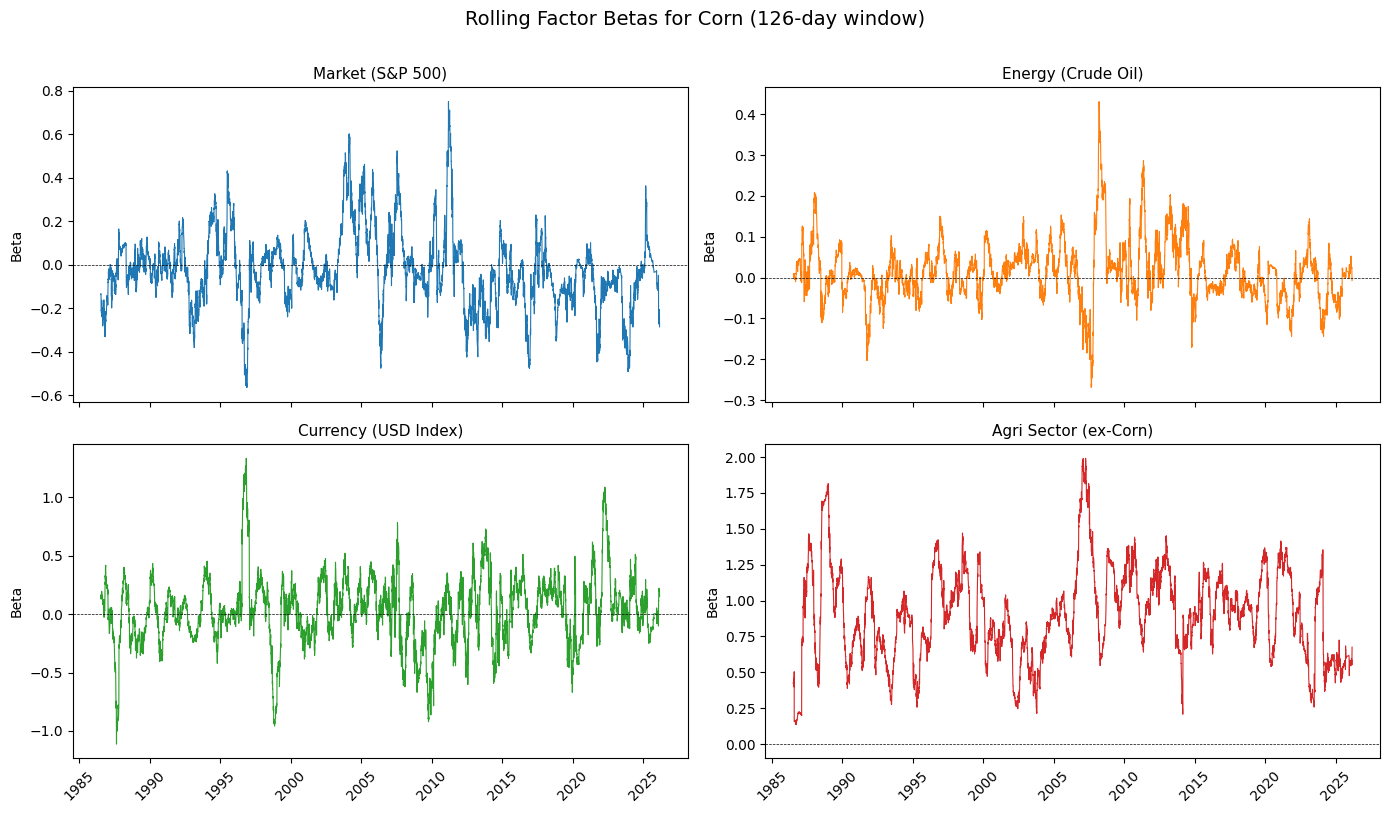

In [6]:
# Plot rolling betas for Corn as an example
target = 'Corn'
betas_df = rolling_betas[target]
factor_names = ['beta_SP500', 'beta_Oil', 'beta_USD', 'beta_Sector']
factor_labels = ['Market (S&P 500)', 'Energy (Crude Oil)', 'Currency (USD Index)', 'Agri Sector (ex-Corn)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for idx, (col, label) in enumerate(zip(factor_names, factor_labels)):
    ax = axes[idx // 2, idx % 2]
    ax.plot(betas_df['Date'], betas_df[col], linewidth=0.8, color=f'C{idx}')
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{label}', fontsize=11)
    ax.set_ylabel('Beta')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f'Rolling Factor Betas for {target} (126-day window)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/rolling_betas_corn.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Regression Diagnostics

To validate the model inspect three key diagnostics across all commodities:

1. **Rolling R-squared**: What fraction of return variance is explained by the four factors? Shows whether the model is actually capturing systematic risk.
2. **Residual Autocorrelation (Ljung-Box test)**: Are the residuals serially independent? Autocorrelated residuals would bias the IVol estimate.
3. **Multicollinearity (Variance Inflation Factor)**: Are the regressors too correlated with each other? High VIF means beta estimates are unstable.

c:\Users\taula\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


=== Rolling R-squared Summary ===
          Corn  Soybean   Wheat  Cotton  Coffee    Oats   Sugar  Soybean_Oil  Lumber
Mean    0.2989   0.3493  0.2196  0.0980  0.0535  0.1284  0.0722       0.2839  0.0538
Median  0.2992   0.3398  0.2028  0.0679  0.0367  0.1025  0.0510       0.2637  0.0430
Min     0.0280   0.0501  0.0022  0.0014  0.0003  0.0016  0.0006       0.0041  0.0014
Max     0.7107   0.7364  0.5644  0.4536  0.3033  0.4318  0.4538       0.7066  0.4038


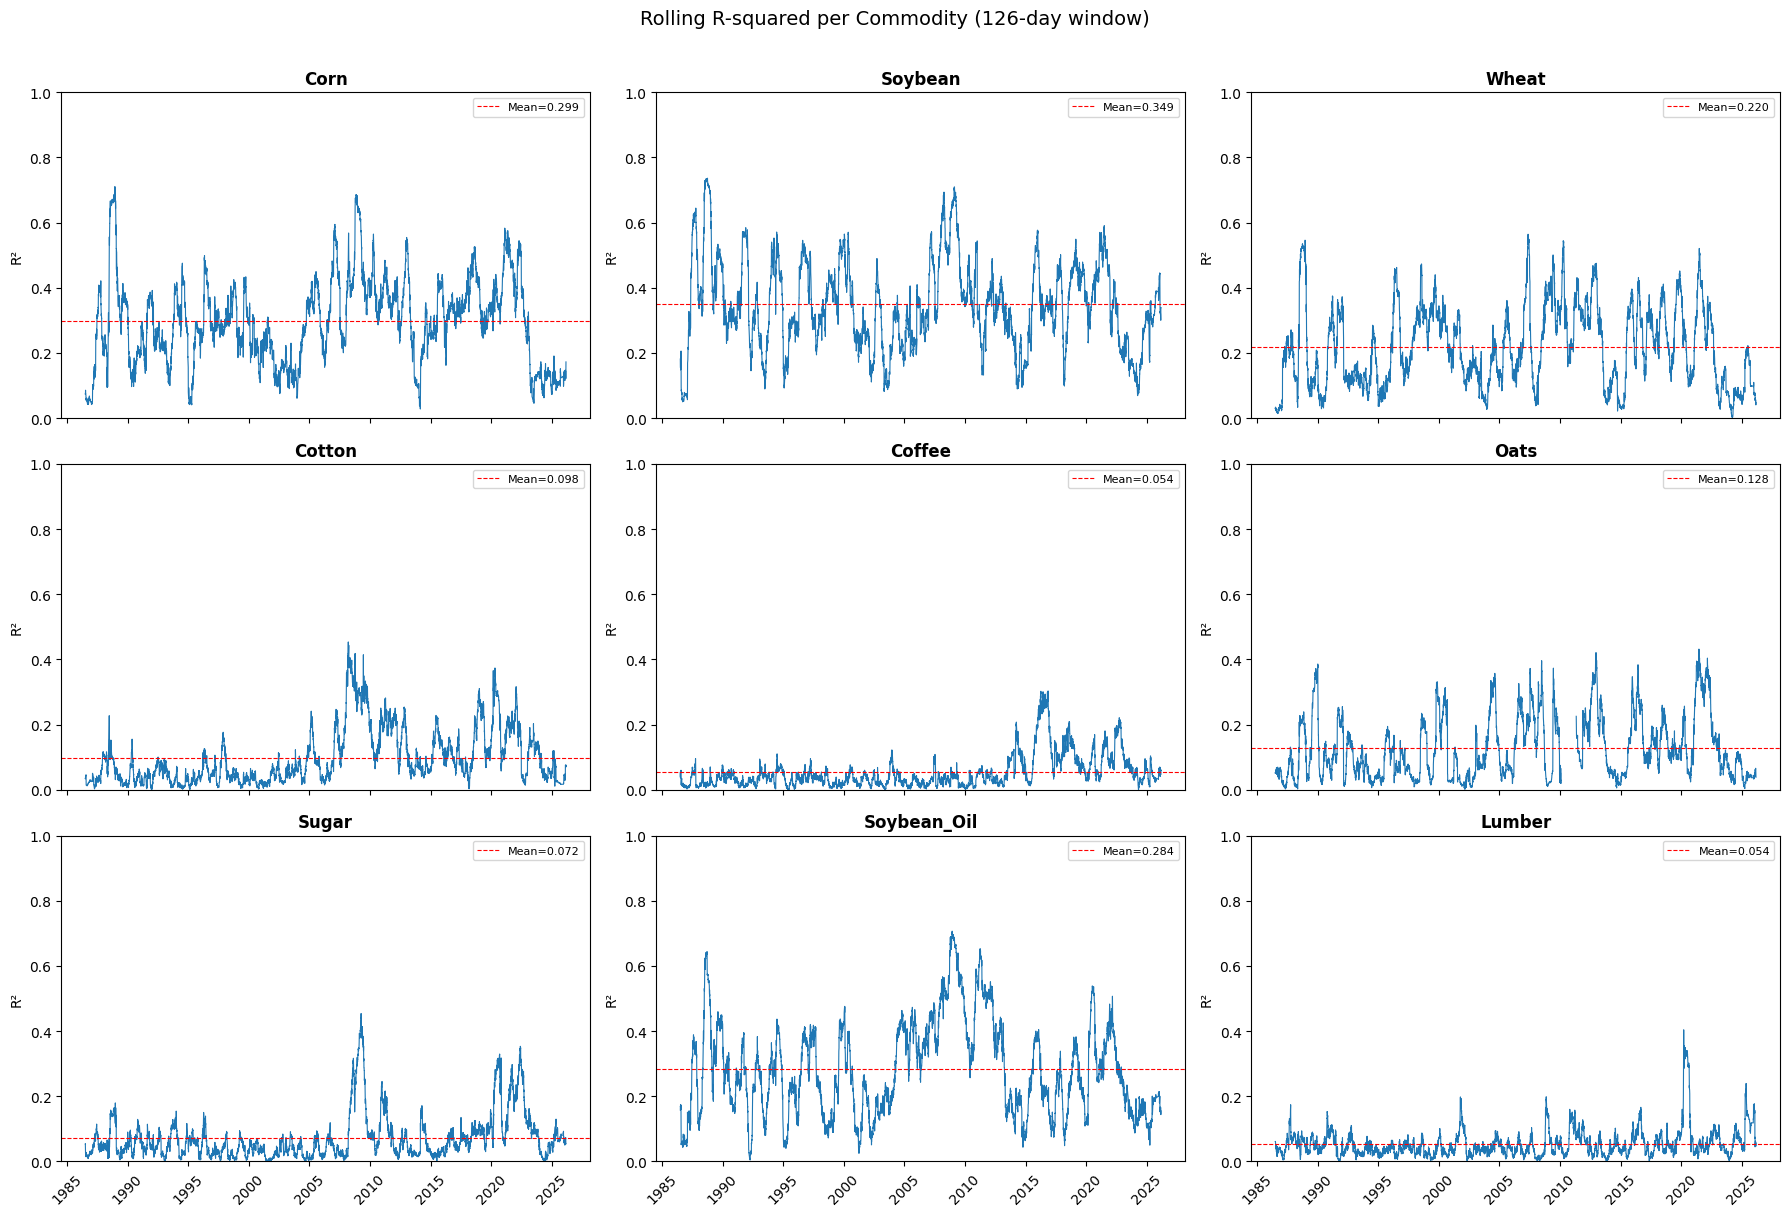


=== Ljung-Box Test for Residual Autocorrelation (10 lags) ===
Commodity         LB Statistic    p-value              Verdict
--------------------------------------------------------------
Corn                     17.59     0.0622   No autocorrelation
Soybean                  37.09     0.0001      AUTOCORRELATION
Wheat                    14.22     0.1633   No autocorrelation
Cotton                   13.86     0.1793   No autocorrelation
Coffee                   18.47     0.0475      AUTOCORRELATION
Oats                     41.25     0.0000      AUTOCORRELATION
Sugar                    54.32     0.0000      AUTOCORRELATION
Soybean_Oil              16.46     0.0872   No autocorrelation
Lumber                  224.33     0.0000      AUTOCORRELATION

=== Variance Inflation Factors (Corn as representative) ===
Factor                    VIF
------------------------------
const                    1.00
SP500                    1.03
Crude_Oil                1.05
USD_Index                1.03
Se

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Rolling R-squared
rolling_r2 = pd.DataFrame({'Date': master['Date']})

for target in COMMODITIES:
    y = master[target].values
    X = np.column_stack([
        master['SP500'].values,
        master['Crude_Oil'].values,
        master['USD_Index'].values,
        sector_indices[target].values
    ])
    X = sm.add_constant(X)

    n = len(y)
    r2 = np.full(n, np.nan)

    for t in range(WINDOW - 1, n):
        start = t - WINDOW + 1
        model = sm.OLS(y[start:t+1], X[start:t+1]).fit()
        r2[t] = model.rsquared

    rolling_r2[target] = r2

# Summary statistics
r2_summary = rolling_r2[COMMODITIES].describe().loc[['mean', '50%', 'min', 'max']]
r2_summary.index = ['Mean', 'Median', 'Min', 'Max']
print('=== Rolling R-squared Summary ===')
print(r2_summary.round(4).to_string())

# Plot rolling R² for all commodities
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
for idx, target in enumerate(COMMODITIES):
    ax = axes[idx // 3, idx % 3]
    ax.plot(master['Date'], rolling_r2[target], linewidth=0.8)
    ax.set_title(target, fontsize=12, fontweight='bold')
    ax.set_ylabel('R²')
    ax.set_ylim(0, 1)
    ax.axhline(y=rolling_r2[target].mean(), color='red', linestyle='--', linewidth=0.8, label=f'Mean={rolling_r2[target].mean():.3f}')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Rolling R-squared per Commodity (126-day window)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/rolling_r2.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Residual Autocorrelation (Ljung-Box)
print('\n=== Ljung-Box Test for Residual Autocorrelation (10 lags) ===')
print(f'{"Commodity":<15} {"LB Statistic":>14} {"p-value":>10} {"Verdict":>20}')
print('-' * 62)
for target in COMMODITIES:
    resid_clean = residuals[target].dropna()
    lb = acorr_ljungbox(resid_clean, lags=10, return_df=True)
    lb_stat = lb['lb_stat'].iloc[-1]
    lb_pval = lb['lb_pvalue'].iloc[-1]
    verdict = 'No autocorrelation' if lb_pval > 0.05 else 'AUTOCORRELATION'
    print(f'{target:<15} {lb_stat:>14.2f} {lb_pval:>10.4f} {verdict:>20}')

# 3. Multicollinearity (VIF)
print('\n=== Variance Inflation Factors (Corn as representative) ===')
X_vif = np.column_stack([
    master['SP500'].values,
    master['Crude_Oil'].values,
    master['USD_Index'].values,
    sector_indices['Corn'].values
])
X_vif = sm.add_constant(X_vif)
vif_names = ['const', 'SP500', 'Crude_Oil', 'USD_Index', 'Sector_ex_Corn']

print(f'{"Factor":<20} {"VIF":>8}')
print('-' * 30)
for i in range(X_vif.shape[1]):
    vif_val = variance_inflation_factor(X_vif, i)
    flag = '  ** HIGH **' if vif_val > 5 and vif_names[i] != 'const' else ''
    print(f'{vif_names[i]:<20} {vif_val:>8.2f}{flag}')

### 2.8 Save Phase 2 Outputs

Export the results for use in Phase 3 (HMM) and Phase 4 (Dashboard):
- **Residuals**: a CSV with Date + residual columns for each commodity.
- **IVol**: a CSV with Date + IVol and Total Vol columns for each commodity.
- **Rolling Betas**: a CSV with Date + beta columns for each commodity.

Save all files to `data/processed/`.

In [ ]:
# Save residuals
residuals.to_csv('data/processed/residuals.csv', index=False)
print(f'Saved residuals: {residuals.shape}')

# Save IVol and Total Vol together
vol_output = pd.DataFrame({'Date': master['Date']})
for target in COMMODITIES:
    vol_output[f'{target}_IVol'] = ivol_df[target]
    vol_output[f'{target}_TotalVol'] = total_vol_df[target]
vol_output.to_csv('data/processed/volatility.csv', index=False)
print(f'Saved volatility: {vol_output.shape}')

# Save rolling betas for all commodities
all_betas = pd.DataFrame({'Date': master['Date']})
for target in COMMODITIES:
    for col in ['alpha', 'beta_SP500', 'beta_Oil', 'beta_USD', 'beta_Sector']:
        all_betas[f'{target}_{col}'] = rolling_betas[target][col]
all_betas.to_csv('data/processed/rolling_betas.csv', index=False)
print(f'Saved rolling betas: {all_betas.shape}')

print('\nAll Phase 2 outputs saved to data/processed/')

Saved residuals: (9601, 10)
Saved volatility: (9601, 19)
Saved rolling betas: (9601, 46)

All Phase 2 outputs saved to data/processed/


: 